
# Project 1 — S&P 500 Correlation Network by GICS Sector

## Research question

**Do S&P 500 stocks from different GICS sectors hold different positions in a stock return correlation network, as measured by degree centrality and eigenvector centrality?**

### Eploration

**Do network features calculated from an earlier period contain useful information about future stock performance relative to the S&P 500?**
https://www.youtube.com/watch?v=mo-Oz6f1uxU 



## Project design

- Nodes: S&P 500 companies
- Categorical node variable: GICS Sector
- Primary edge definition: Two stocks are connected when their 2024 daily percentage returns have a Pearson correlation of at least 0.60.
- Primary edge weight: The actual correlation coefficient between the two stocks.
- Required centrality measures: Degree centrality and eigenvector centrality
- Formation period: 2024
- Future outcome period: 2025
- Future outcome: Stock total return minus SPY total return

The network is undirected because correlation is symmetric. A correlation threshold is needed to convert the correlation matrix into a graph, while retaining the correlation coefficient as the edge weight allows the strength of each relationship to be preserved.



## Why use daily returns instead of raw stock prices?

The primary network uses daily percentage returns, which are the percentage day over day changes in adjusted price.

This is preferable to directly correlating raw price levels because stock prices are nonstationary and often trend over time. Two unrelated stocks can have a high price level correlation simply because both prices generally increased during the same period. Percentage returns remove most of that common trend so a $20 stock and a $500 stock can be compared on the same basis.

Instead of assuming that returns are automatically better, a later section constructs a raw price correlation network with the same number of edges as the return network. This allows the two network definitions to be compared empirically.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import yfinance as yf
import requests

from scipy import stats
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)



# Load S&P 500 companies and categorical information

The S&P 500 constituent table provides the company ticker, company name, GICS sector, and GICS sub-industry. GICS Sector is the categorical node variable required by the assignment.



In [3]:

SP500_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(SP500_URL, headers=headers, timeout=30)
response.raise_for_status()

constituents = pd.read_html(response.text)[0][
    ["Symbol", "Security", "GICS Sector", "GICS Sub-Industry"]
].copy()

constituents["YahooSymbol"] = constituents["Symbol"].str.replace(".", "-", regex=False)

print("Current constituent rows:", len(constituents))
constituents.head()


Current constituent rows: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,YahooSymbol
0,MMM,3M,Industrials,Industrial Conglomerates,MMM
1,AOS,A. O. Smith,Industrials,Building Products,AOS
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,ABT
3,ABBV,AbbVie,Health Care,Biotechnology,ABBV
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,ACN


In [4]:

FORMATION_START = "2024-01-01"
FORMATION_END   = "2025-01-01"

OUTCOME_START   = "2025-01-01"
OUTCOME_END     = "2026-01-01"

CORR_THRESHOLD = 0.60
MIN_FORMATION_OBS = 200

tickers = constituents["YahooSymbol"].tolist()
download_tickers = tickers + ["SPY"]

raw = yf.download(
    download_tickers,
    start=FORMATION_START,
    end=OUTCOME_END,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw[["Close"]].rename(columns={"Close": download_tickers[0]})

prices = prices.sort_index()

print("Downloaded price table shape:", prices.shape)
prices.tail()


ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['FDXF', 'HONA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-01-01 -> 2026-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1704085200, endDate = 1767243600")')


Downloaded price table shape: (502, 504)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,AMD,AME,AMGN,AMP,...,VRTX,VST,VTR,VTRS,VZ,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-12-24,137.494431,273.066711,224.580200,136.779999,122.532806,96.400002,264.528992,352.980011,275.099640,56.612812,252.441833,298.209991,97.778595,112.722343,13.467072,108.919960,84.882553,239.347824,258.422211,88.820000,147.269669,157.839996,206.049988,159.020721,259.853882,39.529137,215.039993,207.336395,327.263550,496.126251,...,462.989990,161.249115,77.705551,11.958107,38.390667,219.001236,384.829987,29.230000,216.850006,179.369751,102.882027,185.698990,93.756531,218.566010,58.180149,110.903748,69.820175,187.498917,276.018494,330.184021,23.142775,124.117218,71.857536,116.875412,137.199112,66.050003,152.097153,89.274048,245.899994,123.553993
2025-12-26,137.563995,272.657867,224.668091,136.820007,122.562256,95.870003,265.616577,353.799988,274.385986,56.740189,253.165604,300.709991,97.749214,113.074265,13.573188,108.211029,84.843315,237.606308,259.125824,88.419998,148.757126,158.369995,204.817932,158.961395,260.969940,39.816269,214.990005,207.505615,326.254211,496.977936,...,462.899994,160.960388,77.705551,12.036264,38.543015,218.552780,386.059998,28.799999,220.699997,181.347641,102.833282,185.857285,93.717178,218.309280,58.238857,111.032928,69.750984,186.628067,273.663940,330.263031,23.123297,123.461990,72.177597,116.767570,137.268356,66.269997,151.032700,89.808319,246.270004,124.282570
2025-12-29,137.106750,273.016876,225.508240,136.619995,122.297188,96.389999,265.861511,353.160004,273.186737,57.043926,253.918701,301.230011,98.189926,113.172020,13.631070,108.270111,84.843315,238.902557,260.770844,88.239998,143.372482,157.839996,205.665588,159.515030,262.115845,40.438400,215.610001,207.744537,323.020386,492.967102,...,459.779999,161.129623,77.734825,12.085113,38.543015,216.410217,385.100006,28.790001,218.990005,179.489609,103.057472,187.618317,92.989166,219.484253,58.512833,111.817932,69.968437,185.193161,274.960968,329.818817,23.191477,121.387077,72.441483,118.159645,136.882675,65.919998,150.076675,89.570862,245.740005,124.036438
2025-12-30,136.798599,272.338684,224.433655,136.910004,123.485107,96.660004,264.548553,352.510010,272.383942,56.994934,253.840500,299.540009,98.660011,113.387085,13.988005,109.097198,84.499931,239.585312,259.472626,87.970001,140.823944,158.139999,206.099274,159.297531,259.046783,40.151268,215.339996,206.092041,322.099213,489.689117,...,453.739990,161.906204,76.954056,12.251198,38.752483,215.941849,383.989990,28.940001,216.929993,175.873444,103.408371,185.995789,92.782562,219.316406,58.865082,111.211784,69.978333,179.512863,276.227997,329.256226,23.366802,119.461098,72.509903,118.610596,136.071701,65.540001,149.987961,90.066887,246.740005,124.459793
2025-12-31,135.257858,271.122009,223.212524,135.720001,123.004051,95.919998,262.882904,349.989990,268.796021,56.328674,251.590897,296.010010,97.798180,112.722343,13.833654,108.575333,83.930916,238.318741,256.460022,87.250000,140.258713,156.149994,205.162888,157.409256,256.077362,39.911987,214.160004,204.379837,320.746887,485.599060,...,453.359985,160.621872,75.981941,12.163270,38.781048,212.713013,379.829987,28.820000,214.779999,172.087463,102.794296,183.631271,91.690544,216.936829,58.816162,110.705017,69.306213,176.732101,274.502014,325.237762,23.074596,119.461098,72.187370,117.973373,134.677261,65.089996,149.100922,89.203812,242.820007,123.878891



## Clean the stock universe

A stock must have at least 200 usable observations during the 2024 formation period.


In [5]:

formation_prices_all = prices.loc[
    (prices.index >= FORMATION_START) &
    (prices.index < FORMATION_END)
].copy()

available_counts = formation_prices_all.notna().sum()

eligible = [
    ticker for ticker in tickers
    if ticker in formation_prices_all.columns
    and available_counts.get(ticker, 0) >= MIN_FORMATION_OBS
]

print(f"Original constituent count: {len(tickers)}")
print(f"Eligible stocks: {len(eligible)}")
print(f"Removed for insufficient 2024 history: {len(tickers) - len(eligible)}")


Original constituent count: 503
Eligible stocks: 496
Removed for insufficient 2024 history: 7



#Create the primary return correlation network

Daily percentage returns are calculated as the day over day percentage change in adjusted closing price. An edge is created when the pairwise return correlation is at 0.60 or greater, then the correlation is saved as an edge weight.


In [6]:

formation_prices = formation_prices_all[eligible].copy()

#Percentage day overday change
formation_returns = formation_prices.pct_change(fill_method=None)

return_corr = formation_returns.corr(min_periods=MIN_FORMATION_OBS)

return_corr.iloc[:5, :5]


Ticker,MMM,AOS,ABT,ABBV,ACN
Ticker,,,,,
MMM,1.000000,0.279235,0.042419,0.123489,0.103161
AOS,0.279235,1.000000,0.113348,0.156556,0.187858
ABT,0.042419,0.113348,1.000000,0.296592,0.170710
ABBV,0.123489,0.156556,0.296592,1.000000,0.020888
ACN,0.103161,0.187858,0.170710,0.020888,1.000000


In [7]:

meta = constituents.set_index("YahooSymbol")

def build_threshold_graph(corr_matrix, nodes, threshold):
    G = nx.Graph()

    for ticker in nodes:
        G.add_node(
            ticker,
            company=meta.loc[ticker, "Security"],
            sector=meta.loc[ticker, "GICS Sector"],
            subindustry=meta.loc[ticker, "GICS Sub-Industry"]
        )

    for i, a in enumerate(nodes):
        for j in range(i + 1, len(nodes)):
            b = nodes[j]
            rho = corr_matrix.loc[a, b]

            if pd.notna(rho) and rho >= threshold:
                G.add_edge(
                    a,
                    b,
                    weight=float(rho),
                    distance=max(1.0 - float(rho), 1e-6)
                )

    return G

G_return = build_threshold_graph(
    return_corr,
    eligible,
    CORR_THRESHOLD
)

print(f"Nodes: {G_return.number_of_nodes()}")
print(f"Edges: {G_return.number_of_edges()}")
print(f"Density: {nx.density(G_return):.6f}")
print(f"Connected components: {nx.number_connected_components(G_return)}")


Nodes: 496
Edges: 936
Density: 0.007625
Connected components: 264



#Centrality measures

## Degree centrality

Degree centrality measures the proportion of all other nodes to which a node is actually directly connected and in this project a high degree stock has strong return correlations with many other stocks.

## Eigenvector centrality

Eigenvector centrality is different and considers not only how many connections a stock has but also how important its neighbors are. A stock can receive a high eigenvector centrality score when it is connected to other highly connected stocks which can be a more telling measure for networking. I would expect this to produce some meaningful value for our purposes here.


In [8]:

def safe_eigenvector_centrality(G, weight=None):
    try:
        return nx.eigenvector_centrality(
            G,
            max_iter=5000,
            tol=1e-9,
            weight=weight
        )
    except nx.PowerIterationFailedConvergence:
        #Fallback for difficult cases
        return nx.eigenvector_centrality_numpy(G, weight=weight)

degree_centrality = nx.degree_centrality(G_return)
eigenvector_centrality = safe_eigenvector_centrality(
    G_return,
    weight=None
)

metrics = pd.DataFrame({
    "Ticker": list(G_return.nodes()),
    "Degree": [G_return.degree(n) for n in G_return.nodes()],
    "Degree_Centrality": [degree_centrality[n] for n in G_return.nodes()],
    "Eigenvector_Centrality": [eigenvector_centrality[n] for n in G_return.nodes()]
})

metrics = metrics.merge(
    constituents[
        ["YahooSymbol", "Symbol", "Security", "GICS Sector", "GICS Sub-Industry"]
    ],
    left_on="Ticker",
    right_on="YahooSymbol",
    how="left"
).drop(columns="YahooSymbol")

metrics = metrics.rename(columns={
    "Security": "Company",
    "GICS Sector": "Sector",
    "GICS Sub-Industry": "SubIndustry"
})

metrics.sort_values("Degree_Centrality", ascending=False).head(15)


,Ticker,Degree,Degree_Centrality,Eigenvector_Centrality,Symbol,Company,Sector,SubIndustry
221,GS,27,0.054545,0.000005,GS,Goldman Sachs,Financials,Investment Banking & Brokerage
373,PRU,26,0.052525,0.000005,PRU,Prudential Financial,Financials,Life & Health Insurance
332,NI,25,0.050505,0.234753,NI,NiSource,Utilities,Multi-Utilities
178,EVRG,25,0.050505,0.235231,EVRG,Evergy,Utilities,Electric Utilities
195,FITB,24,0.048485,0.000005,FITB,Fifth Third Bancorp,Financials,Regional Banks
164,EIX,24,0.048485,0.230397,EIX,Edison International,Utilities,Electric Utilities
368,PPL,24,0.048485,0.234170,PPL,PPL Corporation,Utilities,Electric Utilities
57,BAC,24,0.048485,0.000005,BAC,Bank of America,Financials,Diversified Banks
17,LNT,24,0.048485,0.232014,LNT,Alliant Energy,Utilities,Electric Utilities
157,DTE,23,0.046465,0.225334,DTE,DTE Energy,Utilities,Multi-Utilities



# Compare degree centrality across GICS sectors


In [9]:

sector_required_summary = (
    metrics.groupby("Sector")
    .agg(
        Stocks=("Ticker", "count"),
        Mean_Degree_Centrality=("Degree_Centrality", "mean"),
        Median_Degree_Centrality=("Degree_Centrality", "median"),
        Mean_Eigenvector_Centrality=("Eigenvector_Centrality", "mean"),
        Median_Eigenvector_Centrality=("Eigenvector_Centrality", "median")
    )
    .sort_values("Mean_Degree_Centrality", ascending=False)
)

sector_required_summary


,Stocks,Mean_Degree_Centrality,Median_Degree_Centrality,Mean_Eigenvector_Centrality,Median_Eigenvector_Centrality
Sector,,,,,
Utilities,31,0.030564,0.036364,1.566010e-01,2.006954e-01
Financials,76,0.015444,0.006061,1.502266e-06,9.197656e-08
Real Estate,30,0.012593,0.012121,3.071983e-03,7.180886e-04
Energy,21,0.010967,0.006061,0.000000e+00,0.000000e+00
Information Technology,72,0.006594,0.002020,5.261850e-10,0.000000e+00
Industrials,80,0.004545,0.002020,1.192316e-07,0.000000e+00
Consumer Discretionary,47,0.002321,0.000000,1.847900e-06,0.000000e+00
Materials,25,0.001293,0.000000,4.291699e-09,0.000000e+00
Health Care,59,0.000753,0.000000,0.000000e+00,0.000000e+00


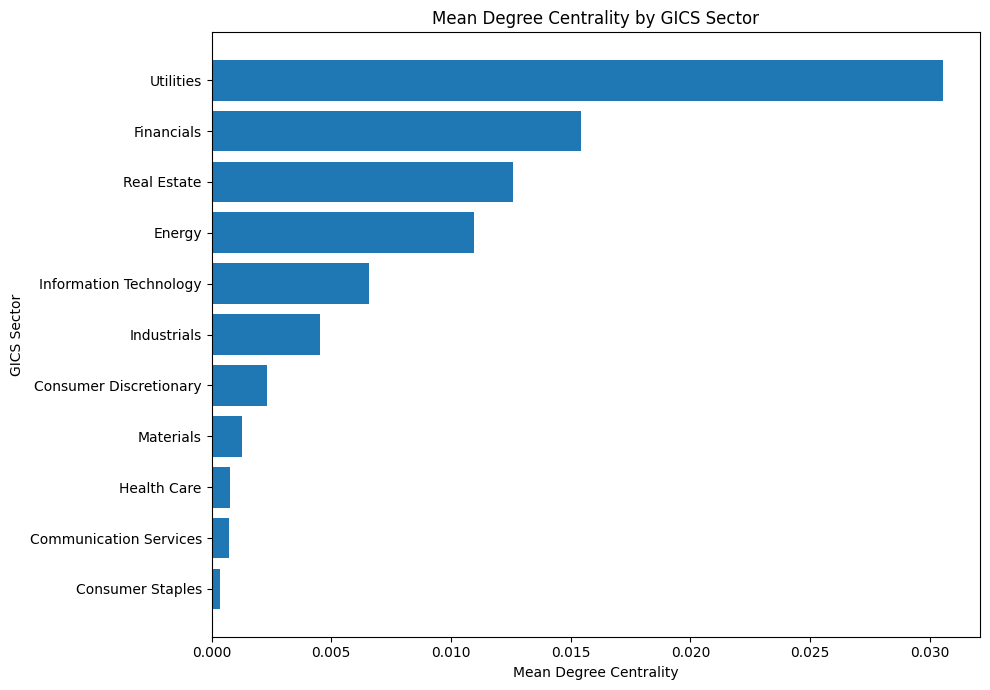

In [10]:

degree_plot = (
    sector_required_summary["Mean_Degree_Centrality"]
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(degree_plot.index, degree_plot.values)
plt.xlabel("Mean Degree Centrality")
plt.ylabel("GICS Sector")
plt.title("Mean Degree Centrality by GICS Sector")
plt.tight_layout()
plt.show()



#Comparing eigenvector centrality across GICS sectors


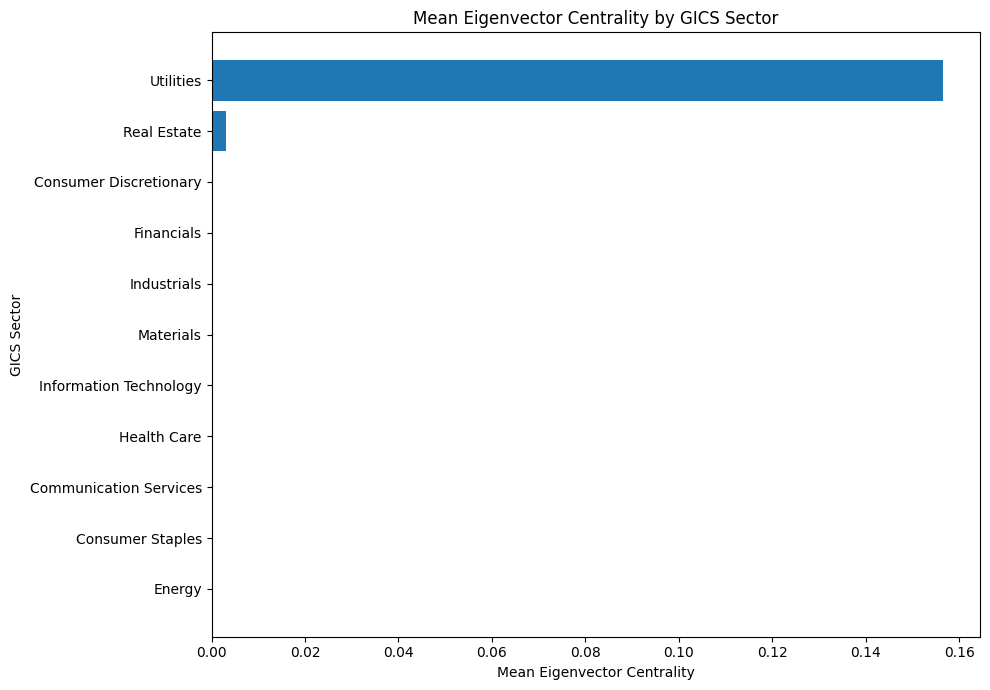

In [11]:

eigen_plot = (
    sector_required_summary["Mean_Eigenvector_Centrality"]
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(eigen_plot.index, eigen_plot.values)
plt.xlabel("Mean Eigenvector Centrality")
plt.ylabel("GICS Sector")
plt.title("Mean Eigenvector Centrality by GICS Sector")
plt.tight_layout()
plt.show()



#Statistical comparison across categorical groups and hypothesis

Degree and eigenvector centrality can be highly skewed especially in a sparse threshold network. For each centrality measure the Null hypothesis is the sector distributions are the same. Alternative hypothesis is that at least one sector distribution differs. Our result establishes in this dataset that at least one sector differs, but it does not show every individual specific pair of sectors that differ.


In [12]:

degree_groups = [
    group["Degree_Centrality"].values
    for _, group in metrics.groupby("Sector")
    if len(group) >= 2
]

eigen_groups = [
    group["Eigenvector_Centrality"].values
    for _, group in metrics.groupby("Sector")
    if len(group) >= 2
]

kw_degree = stats.kruskal(*degree_groups)
kw_eigen = stats.kruskal(*eigen_groups)

print("Kruskal-Wallis: Degree centrality across sectors")
print(f"H = {kw_degree.statistic:.4f}, p = {kw_degree.pvalue:.6g}")

print("\nKruskal-Wallis: Eigenvector centrality across sectors")
print(f"H = {kw_eigen.statistic:.4f}, p = {kw_eigen.pvalue:.6g}")


Kruskal-Wallis: Degree centrality across sectors
H = 183.0721, p = 5.39196e-34

Kruskal-Wallis: Eigenvector centrality across sectors
H = 237.9198, p = 1.87274e-45



## Interpretation of the required centrality results

The 2024 return correlation network is relatively sparse as we have 496 eligible stocks and 936 edges at a correlation threshold of 0.60. Degree centrality and eigenvector centrality were very different across GICS sectors, and the Kruskal Wallis tests indicated statistically significant differences across sectors for both measures. Utilities and Financials were at more connected positions in the network, while several other sectors have very low or zero centrality. These results suggest that stock return relationships are not distributed evenly across economic sectors which is information we expected to be reinforced here.

The network is highly disconnected and has separate connected component rather than one unified graph. This is important for interpreting eigenvector centrality because eigenvector scores are influenced by the structure of the connected component. Stocks in larger or more internally connected components can have much higher eigenvector centrality values than stocks in small or isolated components even when their local degree is similar.



#Analysis of the Two Largest Connected Components

Since the full graph contains many disconnected components, I wanted to narrow in on the two largest connected components separately. This allows centrality measures to be interpreted within more coherent portions of the network and helps identify whether the major components are dominated by particular GICS sectors.


In [13]:

# Sort connected components from largest to smallest
components = sorted(
    nx.connected_components(G_return),
    key=len,
    reverse=True
)

largest_component_nodes = components[0]
second_component_nodes = components[1]

G_component1 = G_return.subgraph(largest_component_nodes).copy()
G_component2 = G_return.subgraph(second_component_nodes).copy()

print("Total connected components:", len(components))
print("Largest component size:", G_component1.number_of_nodes())
print("Second-largest component size:", G_component2.number_of_nodes())
print("Largest component edges:", G_component1.number_of_edges())
print("Second-largest component edges:", G_component2.number_of_edges())


Total connected components: 264
Largest component size: 173
Second-largest component size: 11
Largest component edges: 830
Second-largest component edges: 47



## Sector composition of the two largest components

The tables below show which GICS sectors are represented in each of the two largest connected components. This helps determine whether the largest pieces of the network are broadly mixed or dominated by particular sectors.


In [14]:

def component_sector_summary(G):
    rows = [
        {
            "Ticker": node,
            "Sector": G.nodes[node]["sector"]
        }
        for node in G.nodes()
    ]

    df = pd.DataFrame(rows)

    summary = (
        df["Sector"]
        .value_counts()
        .rename_axis("Sector")
        .reset_index(name="Stocks")
    )

    summary["Share"] = summary["Stocks"] / summary["Stocks"].sum()
    return summary

component1_sectors = component_sector_summary(G_component1)
component2_sectors = component_sector_summary(G_component2)

print("Largest component sector composition")
display(component1_sectors)

print("\nSecond-largest component sector composition")
display(component2_sectors)


Largest component sector composition


,Sector,Stocks,Share
0,Financials,47,0.271676
1,Industrials,32,0.184971
2,Utilities,30,0.173410
3,Information Technology,27,0.156069
4,Real Estate,24,0.138728
5,Consumer Discretionary,9,0.052023
6,Materials,4,0.023121



Second-largest component sector composition


,Sector,Stocks,Share
0,Energy,11,1.0



## Recalculate centrality within each component

Degree centrality and eigenvector centrality are recalculated within each component rather than copied from the full disconnected graph.


In [15]:

def component_centrality_table(G, component_name):
    degree = nx.degree_centrality(G)

    eigen = safe_eigenvector_centrality(
        G,
        weight=None
    )

    strength = dict(G.degree(weight="weight"))

    weighted_eigen = safe_eigenvector_centrality(
        G,
        weight="weight"
    )

    rows = []

    for node in G.nodes():
        rows.append({
            "Component": component_name,
            "Ticker": node,
            "Company": G.nodes[node]["company"],
            "Sector": G.nodes[node]["sector"],
            "Degree_Centrality": degree[node],
            "Eigenvector_Centrality": eigen[node],
            "Strength": strength[node],
            "Weighted_Eigenvector": weighted_eigen[node]
        })

    return pd.DataFrame(rows)

component1_metrics = component_centrality_table(
    G_component1,
    "Largest component"
)

component2_metrics = component_centrality_table(
    G_component2,
    "Second-largest component"
)

print("Top stocks in largest component by eigenvector centrality")
display(
    component1_metrics
    .sort_values("Eigenvector_Centrality", ascending=False)
    .head(10)
)

print("\nTop stocks in second-largest component by eigenvector centrality")
display(
    component2_metrics
    .sort_values("Eigenvector_Centrality", ascending=False)
    .head(10)
)


Top stocks in largest component by eigenvector centrality


,Component,Ticker,Company,Sector,Degree_Centrality,Eigenvector_Centrality,Strength,Weighted_Eigenvector
116,Largest component,EVRG,Evergy,Utilities,0.145349,0.235231,18.235049,0.244272
162,Largest component,NI,NiSource,Utilities,0.145349,0.234753,17.854490,0.238360
7,Largest component,PPL,PPL Corporation,Utilities,0.139535,0.234170,17.777587,0.245383
153,Largest component,LNT,Alliant Energy,Utilities,0.139535,0.232014,17.516649,0.240670
15,Largest component,EIX,Edison International,Utilities,0.139535,0.230397,16.769111,0.227958
121,Largest component,DUK,Duke Energy,Utilities,0.127907,0.227848,15.656506,0.228388
72,Largest component,SO,Southern Company,Utilities,0.127907,0.227848,15.387768,0.224355
96,Largest component,FE,FirstEnergy,Utilities,0.127907,0.227838,15.353908,0.223920
117,Largest component,DTE,DTE Energy,Utilities,0.133721,0.225334,16.764723,0.234453
99,Largest component,CMS,CMS Energy,Utilities,0.122093,0.224397,15.451749,0.232298



Top stocks in second-largest component by eigenvector centrality


,Component,Ticker,Company,Sector,Degree_Centrality,Eigenvector_Centrality,Strength,Weighted_Eigenvector
9,Second-largest component,HAL,Halliburton,Energy,1.0,0.327648,7.073432,0.328358
2,Second-largest component,DVN,Devon Energy,Energy,1.0,0.327648,7.374710,0.345441
10,Second-largest component,OXY,Occidental Petroleum,Energy,0.9,0.316857,6.559679,0.327432
6,Second-largest component,APA,APA Corporation,Energy,0.9,0.316857,6.128186,0.308270
0,Second-largest component,CVX,Chevron Corporation,Energy,0.9,0.316857,6.157298,0.309001
3,Second-largest component,EOG,EOG Resources,Energy,0.9,0.316857,6.438708,0.321950
4,Second-largest component,FANG,Diamondback Energy,Energy,0.9,0.316857,6.277041,0.314843
5,Second-largest component,COP,ConocoPhillips,Energy,0.9,0.316857,6.443224,0.322171
1,Second-largest component,SLB,Schlumberger,Energy,0.9,0.298732,5.744977,0.269088
7,Second-largest component,XOM,ExxonMobil,Energy,0.8,0.286730,5.717793,0.293461



## Compare sector-level centrality inside each component

The following summaries show whether the sector patterns seen in the full network are also present within the two largest connected components.


In [16]:

component1_sector_centrality = (
    component1_metrics
    .groupby("Sector")
    .agg(
        Stocks=("Ticker", "count"),
        Mean_Degree_Centrality=("Degree_Centrality", "mean"),
        Mean_Eigenvector_Centrality=("Eigenvector_Centrality", "mean"),
        Mean_Strength=("Strength", "mean")
    )
    .sort_values("Mean_Eigenvector_Centrality", ascending=False)
)

component2_sector_centrality = (
    component2_metrics
    .groupby("Sector")
    .agg(
        Stocks=("Ticker", "count"),
        Mean_Degree_Centrality=("Degree_Centrality", "mean"),
        Mean_Eigenvector_Centrality=("Eigenvector_Centrality", "mean"),
        Mean_Strength=("Strength", "mean")
    )
    .sort_values("Mean_Eigenvector_Centrality", ascending=False)
)

print("Largest component")
display(component1_sector_centrality)

print("\nSecond-largest component")
display(component2_sector_centrality)


Largest component


,Stocks,Mean_Degree_Centrality,Mean_Eigenvector_Centrality,Mean_Strength
Sector,,,,
Utilities,30,0.090891,1.618210e-01,10.983241
Real Estate,24,0.044331,3.839979e-03,5.123548
Consumer Discretionary,9,0.025840,9.650113e-06,3.279767
Financials,47,0.070139,8.499419e-07,8.260820
Industrials,32,0.029797,2.789666e-07,3.326746
Materials,4,0.017442,2.264575e-08,2.028762
Information Technology,27,0.048450,6.317755e-10,5.669626



Second-largest component


,Stocks,Mean_Degree_Centrality,Mean_Eigenvector_Centrality,Mean_Strength
Sector,,,,
Energy,11,0.854545,0.295355,5.993748



## Visualize the two largest connected components

The two graphs below use correlation as the spring layout weight. Stronger correlations exert a stronger attractive force, so highly correlated stocks tend to appear closer together. The physical distance between nodes is still a visualization result and should not be interpreted as an exact numerical transformation of correlation.


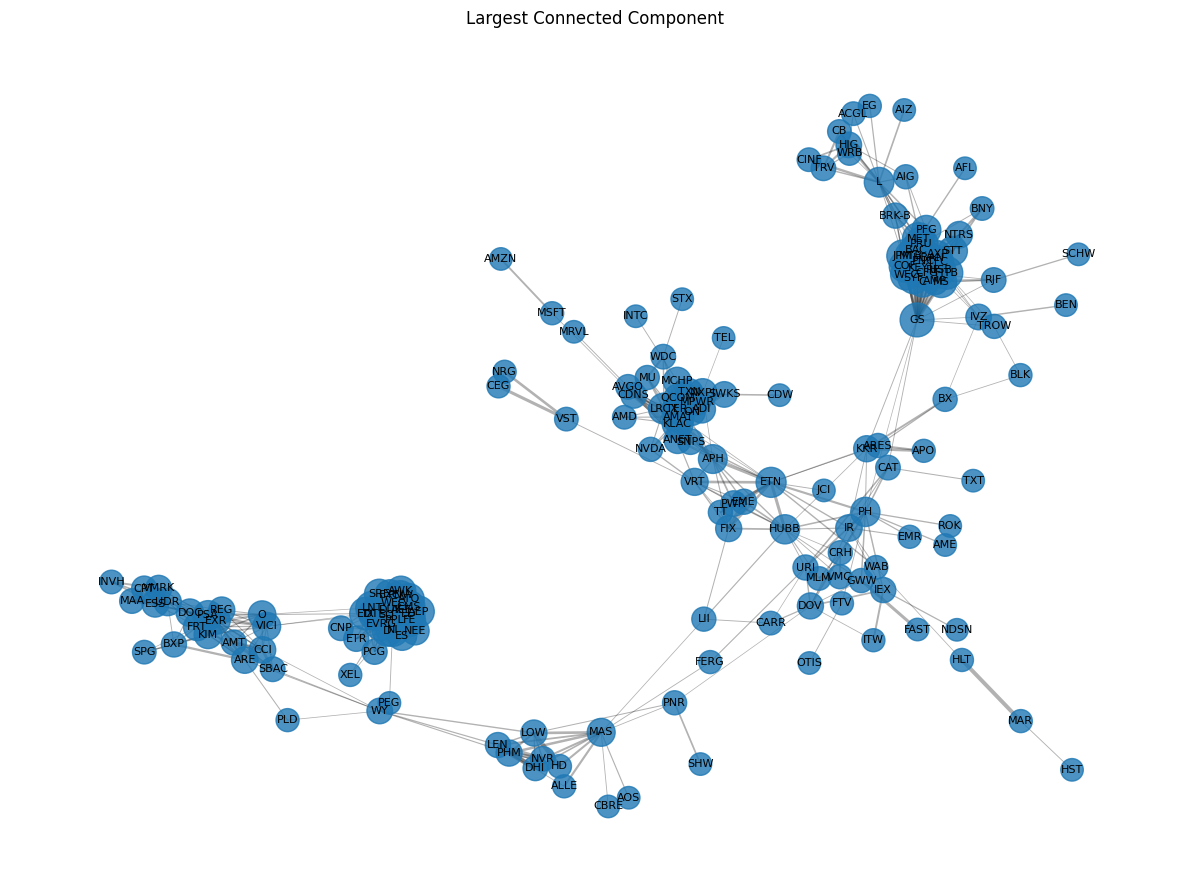

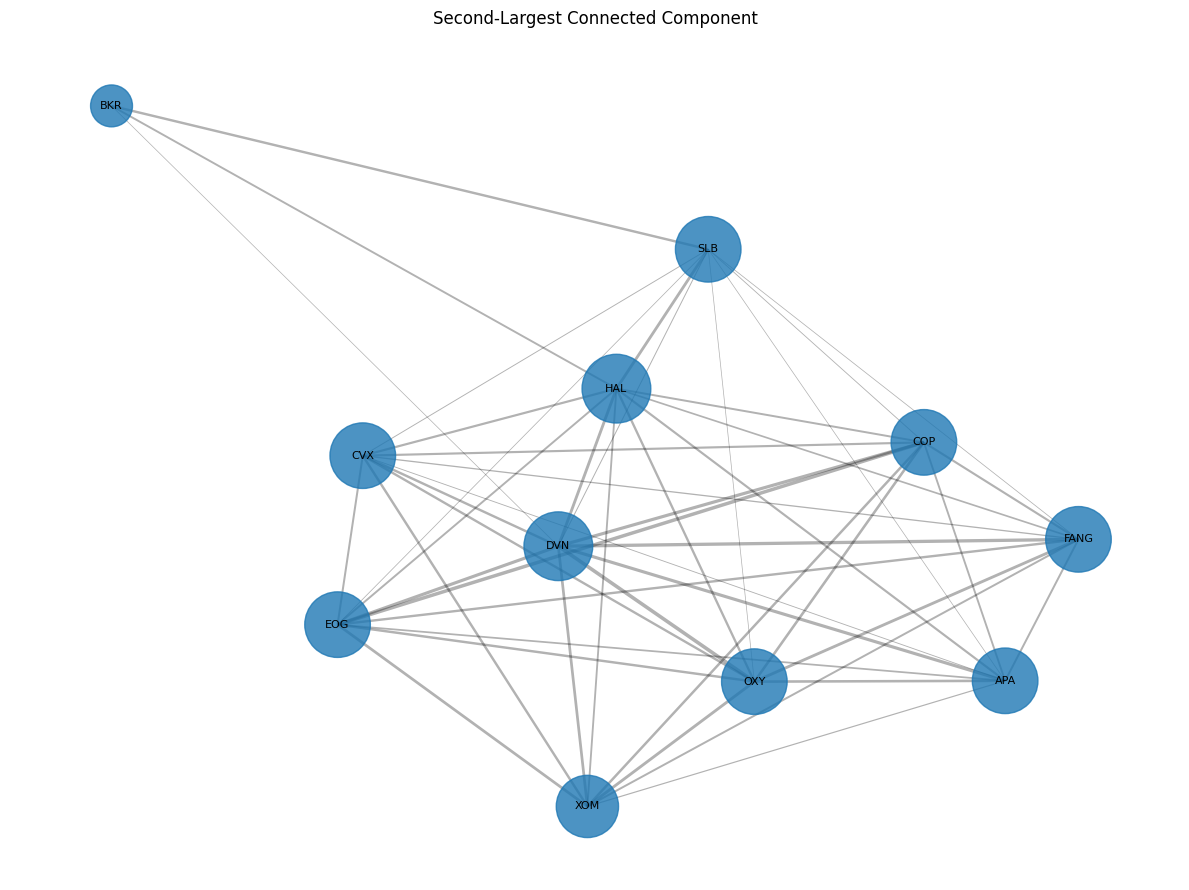

In [17]:

def draw_component(G, title):
    plt.figure(figsize=(12, 9))

    pos = nx.spring_layout(
        G,
        seed=42,
        weight="weight"
    )

    local_degree = nx.degree_centrality(G)

    node_sizes = [
        250 + 2200 * local_degree[n]
        for n in G.nodes()
    ]

    edge_widths = [
        0.5 + 4 * ((G[u][v]["weight"] - CORR_THRESHOLD) / (1 - CORR_THRESHOLD))
        for u, v in G.edges()
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        alpha=0.8
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.30
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_component(
    G_component1,
    "Largest Connected Component"
)

draw_component(
    G_component2,
    "Second-Largest Connected Component"
)



#Weighted network features weighted degree, Weighted eigenvector centrality, Weighted clustering

The graph already stores the return correlation as the edge weight so this section uses those weights rather than treating all retained edges as equal strength. Weighted degree can be called node strength and is the sum of all correlation weights attached to a stock in our case. This is meant to separate a stock with many strong relationships from a stock with the same or similar number of weaker relationships. Weighted eigenvector centrality allows the weight of stronger correlations to contribute more heavily when evaluating whether a stock's connections. Finally, weighted clustering incorporates the strength of connections when measuring how tightly interconnected a stock's local neighborhood is.


In [18]:

strength = dict(G_return.degree(weight="weight"))

weighted_eigenvector = safe_eigenvector_centrality(
    G_return,
    weight="weight"
)

weighted_clustering = nx.clustering(
    G_return,
    weight="weight"
)

metrics["Strength"] = metrics["Ticker"].map(strength)
metrics["Weighted_Eigenvector"] = metrics["Ticker"].map(weighted_eigenvector)
metrics["Weighted_Clustering"] = metrics["Ticker"].map(weighted_clustering)

metrics[
    [
        "Ticker",
        "Sector",
        "Degree_Centrality",
        "Eigenvector_Centrality",
        "Strength",
        "Weighted_Eigenvector",
        "Weighted_Clustering"
    ]
].sort_values("Strength", ascending=False).head(15)


,Ticker,Sector,Degree_Centrality,Eigenvector_Centrality,Strength,Weighted_Eigenvector,Weighted_Clustering
178,EVRG,Utilities,0.050505,0.235231,18.235049,2.442716e-01,0.497741
221,GS,Financials,0.054545,0.000005,18.215728,1.003790e-06,0.374584
332,NI,Utilities,0.050505,0.234753,17.854490,2.383605e-01,0.487921
368,PPL,Utilities,0.048485,0.234170,17.777587,2.453834e-01,0.541510
17,LNT,Utilities,0.048485,0.232014,17.516649,2.406704e-01,0.526879
373,PRU,Financials,0.052525,0.000005,17.157701,9.901971e-07,0.423568
195,FITB,Financials,0.048485,0.000005,17.052748,1.064734e-06,0.501516
57,BAC,Financials,0.048485,0.000005,17.021545,1.065470e-06,0.512315
164,EIX,Utilities,0.048485,0.230397,16.769111,2.279575e-01,0.505559
157,DTE,Utilities,0.046465,0.225334,16.764723,2.344534e-01,0.543966



#Is day over day change better than correlating raw prices?

To test this instead of only arguing it theoretically, a second network was built from raw adjusted price level correlations. Using the same 0.60 cutoff for both networks could lead to an unfair comparison because raw prices may naturally produce a denser graph. To account for this the price network is density matched to the return network by retaining the same number of strongest pairwise correlations.

This lets us hold the number of edges but about constant but still compare two things, the daily percentage return correlations and the raw adjusted price correlations. If the two produce very different centrality rankings or predictive performance, that is evidence supporting the idea that the choice of transformation matters in this case.


In [19]:

price_corr = formation_prices.corr(min_periods=MIN_FORMATION_OBS)

def build_top_k_graph(corr_matrix, nodes, k):
    G = nx.Graph()

    for ticker in nodes:
        G.add_node(
            ticker,
            company=meta.loc[ticker, "Security"],
            sector=meta.loc[ticker, "GICS Sector"],
            subindustry=meta.loc[ticker, "GICS Sub-Industry"]
        )

    pairs = []

    for i, a in enumerate(nodes):
        for j in range(i + 1, len(nodes)):
            b = nodes[j]
            rho = corr_matrix.loc[a, b]
            if pd.notna(rho):
                pairs.append((a, b, float(rho)))

    pairs.sort(key=lambda x: x[2], reverse=True)

    for a, b, rho in pairs[:k]:
        G.add_edge(
            a,
            b,
            weight=rho,
            distance=max(1.0 - rho, 1e-6)
        )

    return G

G_price = build_top_k_graph(
    price_corr,
    eligible,
    G_return.number_of_edges()
)

print("RETURN NETWORK")
print("Edges:", G_return.number_of_edges())
print("Density:", nx.density(G_return))

print("\nPRICE NETWORK — MATCHED EDGE COUNT")
print("Edges:", G_price.number_of_edges())
print("Density:", nx.density(G_price))


RETURN NETWORK
Edges: 936
Density: 0.007624633431085044

PRICE NETWORK — MATCHED EDGE COUNT
Edges: 936
Density: 0.007624633431085044


In [20]:

price_degree = nx.degree_centrality(G_price)
price_eigen = safe_eigenvector_centrality(G_price, weight=None)
price_strength = dict(G_price.degree(weight="weight"))
price_weighted_eigen = safe_eigenvector_centrality(G_price, weight="weight")
price_weighted_clustering = nx.clustering(G_price, weight="weight")

price_metrics = pd.DataFrame({
    "Ticker": eligible,
    "Price_Degree_Centrality": [price_degree[n] for n in eligible],
    "Price_Eigenvector_Centrality": [price_eigen[n] for n in eligible],
    "Price_Strength": [price_strength[n] for n in eligible],
    "Price_Weighted_Eigenvector": [price_weighted_eigen[n] for n in eligible],
    "Price_Weighted_Clustering": [price_weighted_clustering[n] for n in eligible]
})

comparison_metrics = metrics.merge(
    price_metrics,
    on="Ticker",
    how="left"
)

comparison_metrics.head()


,Ticker,Degree,Degree_Centrality,Eigenvector_Centrality,Symbol,Company,Sector,SubIndustry,Strength,Weighted_Eigenvector,Weighted_Clustering,Price_Degree_Centrality,Price_Eigenvector_Centrality,Price_Strength,Price_Weighted_Eigenvector,Price_Weighted_Clustering
0,MMM,0,0.00000,0.000000e+00,MMM,3M,Industrials,Industrial Conglomerates,0.000000,0.000000e+00,0.0,0.030303,1.785784e-02,14.422637,1.778592e-02,0.596852
1,AOS,1,0.00202,2.368451e-07,AOS,A. O. Smith,Industrials,Building Products,0.632438,1.168825e-07,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000
2,ABT,0,0.00000,0.000000e+00,ABT,Abbott Laboratories,Health Care,Health Care Equipment,0.000000,0.000000e+00,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000
3,ABBV,0,0.00000,0.000000e+00,ABBV,AbbVie,Health Care,Biotechnology,0.000000,0.000000e+00,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000
4,ACN,1,0.00202,0.000000e+00,ACN,Accenture,Information Technology,IT Consulting & Other Services,0.636759,0.000000e+00,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000



## Compare stock rankings under the two network definitions

Spearman correlation compares whether stocks receive similar relative rankings under the return-based and price-based networks.


In [21]:

rank_comparisons = pd.DataFrame({
    "Metric": [
        "Degree centrality",
        "Eigenvector centrality",
        "Weighted degree / strength",
        "Weighted eigenvector"
    ],
    "Spearman_rho": [
        stats.spearmanr(
            comparison_metrics["Degree_Centrality"],
            comparison_metrics["Price_Degree_Centrality"]
        ).statistic,
        stats.spearmanr(
            comparison_metrics["Eigenvector_Centrality"],
            comparison_metrics["Price_Eigenvector_Centrality"]
        ).statistic,
        stats.spearmanr(
            comparison_metrics["Strength"],
            comparison_metrics["Price_Strength"]
        ).statistic,
        stats.spearmanr(
            comparison_metrics["Weighted_Eigenvector"],
            comparison_metrics["Price_Weighted_Eigenvector"]
        ).statistic
    ]
})

rank_comparisons


,Metric,Spearman_rho
0,Degree centrality,0.317534
1,Eigenvector centrality,0.297850
2,Weighted degree / strength,0.325795
3,Weighted eigenvector,0.281123



#Future performance relative to SPY

The prediction extension uses the network features from 2024 to explain or predict performance during 2025. The primary outcome remains continuous excess return which is Stock 2025 Return − SPY 2025 Return. Using excess return helps to see outperformance or underperformance, making it more useful than a simple binary classification comparing regression and forecasting methods.



In [22]:

outcome_prices = prices.loc[
    (prices.index >= OUTCOME_START) &
    (prices.index < OUTCOME_END)
].copy()

def period_return(series):
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    return (s.iloc[-1] / s.iloc[0]) - 1

stock_returns_2025 = {
    ticker: period_return(outcome_prices[ticker])
    for ticker in eligible
    if ticker in outcome_prices.columns
}

spy_return_2025 = period_return(outcome_prices["SPY"])

outcomes = pd.DataFrame({
    "Ticker": list(stock_returns_2025.keys()),
    "Future_Return": list(stock_returns_2025.values())
})

outcomes["SPY_Return"] = spy_return_2025
outcomes["Excess_Return"] = outcomes["Future_Return"] - outcomes["SPY_Return"]
outcomes["Outperform"] = (outcomes["Excess_Return"] > 0).astype(int)

analysis_df = comparison_metrics.merge(
    outcomes,
    on="Ticker",
    how="inner"
).dropna(subset=["Excess_Return"])

print(f"SPY 2025 return: {spy_return_2025:.2%}")
print(f"Stocks with future outcome data: {len(analysis_df)}")
print(f"Share outperforming SPY: {analysis_df['Outperform'].mean():.2%}")

analysis_df.head()


SPY 2025 return: 18.01%
Stocks with future outcome data: 496
Share outperforming SPY: 33.87%


,Ticker,Degree,Degree_Centrality,Eigenvector_Centrality,Symbol,Company,Sector,SubIndustry,Strength,Weighted_Eigenvector,Weighted_Clustering,Price_Degree_Centrality,Price_Eigenvector_Centrality,Price_Strength,Price_Weighted_Eigenvector,Price_Weighted_Clustering,Future_Return,SPY_Return,Excess_Return,Outperform
0,MMM,0,0.00000,0.000000e+00,MMM,3M,Industrials,Industrial Conglomerates,0.000000,0.000000e+00,0.0,0.030303,1.785784e-02,14.422637,1.778592e-02,0.596852,0.257692,0.18009,0.077602,1
1,AOS,1,0.00202,2.368451e-07,AOS,A. O. Smith,Industrials,Building Products,0.632438,1.168825e-07,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000,0.013762,0.18009,-0.166329,0
2,ABT,0,0.00000,0.000000e+00,ABT,Abbott Laboratories,Health Care,Health Care Equipment,0.000000,0.000000e+00,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000,0.125388,0.18009,-0.054702,0
3,ABBV,0,0.00000,0.000000e+00,ABBV,AbbVie,Health Care,Biotechnology,0.000000,0.000000e+00,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000,0.317874,0.18009,0.137784,1
4,ACN,1,0.00202,0.000000e+00,ACN,Accenture,Information Technology,IT Consulting & Other Services,0.636759,0.000000e+00,0.0,0.000000,6.389022e-45,0.000000,1.817070e-44,0.000000,-0.219854,0.18009,-0.399944,0



#Association models

These OLS models ask whether network position measured during 2024 is associated with 2025 excess return. Three versions are compared
- Required centralities is just going to be degree + eigenvector
- Weighted return network features is using strength + weighted eigenvector + weighted clustering
- Weighted raw price network features are a group of equivalent measures from the price level network


In [23]:

model_required = smf.ols(
    "Excess_Return ~ Degree_Centrality + Eigenvector_Centrality + C(Sector)",
    data=analysis_df
).fit(cov_type="HC3")

model_weighted_returns = smf.ols(
    "Excess_Return ~ Strength + Weighted_Eigenvector + Weighted_Clustering + C(Sector)",
    data=analysis_df
).fit(cov_type="HC3")

model_weighted_prices = smf.ols(
    "Excess_Return ~ Price_Strength + Price_Weighted_Eigenvector + Price_Weighted_Clustering + C(Sector)",
    data=analysis_df
).fit(cov_type="HC3")

model_comparison = pd.DataFrame({
    "Model": [
        "Required centralities — return network",
        "Weighted features — return network",
        "Weighted features — raw-price network"
    ],
    "R_squared": [
        model_required.rsquared,
        model_weighted_returns.rsquared,
        model_weighted_prices.rsquared
    ],
    "Adjusted_R_squared": [
        model_required.rsquared_adj,
        model_weighted_returns.rsquared_adj,
        model_weighted_prices.rsquared_adj
    ],
    "AIC": [
        model_required.aic,
        model_weighted_returns.aic,
        model_weighted_prices.aic
    ],
    "BIC": [
        model_required.bic,
        model_weighted_returns.bic,
        model_weighted_prices.bic
    ]
})

model_comparison


,Model,R_squared,Adjusted_R_squared,AIC,BIC
0,Required centralities — return network,0.069031,0.045901,578.428192,633.113679
1,Weighted features — return network,0.068865,0.043751,580.516891,639.408954
2,Weighted features — raw-price network,0.063782,0.038531,583.216877,642.108940



##Detailed weighted return model

This is the model that most directly is made to test whether the strength of correlation network relationships contains useful information about future excess return.


In [24]:

print(model_weighted_returns.summary())


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     3.257
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           9.37e-05
Time:                        02:35:25   Log-Likelihood:                -276.26
No. Observations:                 496   AIC:                             580.5
Df Residuals:                     482   BIC:                             639.4
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In


#Cross validated prediction comparison

OLS is useful for interpretation, but in sample R-squared does not tell us how well the features generalize so this section uses Ridge regression with 5 fold cross validation to compare a return network feature set and a raw price network feature set. The target is continuous 2025 excess return and Mean Absolute Error (MAE) is the primary prediction metric because future stock returns can have big outliers. A stronger future project could repeat the network construction through time using rolling weekly or monthly windows with a lot more data.


In [25]:

def evaluate_feature_set(df, numeric_features, label):
    X = df[numeric_features + ["Sector"]].copy()
    y = df["Excess_Return"].copy()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("sector", OneHotEncoder(handle_unknown="ignore"), ["Sector"])
        ]
    )

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=1.0))
    ])

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "R2": "r2"
        }
    )

    return {
        "Feature_Set": label,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_MAE_SD": scores["test_MAE"].std(),
        "CV_R2": scores["test_R2"].mean(),
        "CV_R2_SD": scores["test_R2"].std()
    }

return_features = [
    "Degree_Centrality",
    "Eigenvector_Centrality",
    "Strength",
    "Weighted_Eigenvector",
    "Weighted_Clustering"
]

price_features = [
    "Price_Degree_Centrality",
    "Price_Eigenvector_Centrality",
    "Price_Strength",
    "Price_Weighted_Eigenvector",
    "Price_Weighted_Clustering"
]

prediction_comparison = pd.DataFrame([
    evaluate_feature_set(
        analysis_df,
        return_features,
        "Daily-return correlation network"
    ),
    evaluate_feature_set(
        analysis_df,
        price_features,
        "Raw-price correlation network"
    )
])

prediction_comparison


,Feature_Set,CV_MAE,CV_MAE_SD,CV_R2,CV_R2_SD
0,Daily-return correlation network,0.264255,0.022271,0.006581,0.113570
1,Raw-price correlation network,0.266592,0.021679,0.000204,0.108552



#Correlation-threshold sensitivity

The 0.60 threshold is a modeling choice rather than a natural law. This section tests several thresholds to determine whether the basic return-network structure is robust.


In [26]:

threshold_rows = []

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:
    G_temp = build_threshold_graph(
        return_corr,
        eligible,
        threshold
    )

    degree_temp = nx.degree_centrality(G_temp)
    eigen_temp = safe_eigenvector_centrality(
        G_temp,
        weight=None
    )
    strength_temp = dict(G_temp.degree(weight="weight"))

    threshold_rows.append({
        "Threshold": threshold,
        "Nodes": G_temp.number_of_nodes(),
        "Edges": G_temp.number_of_edges(),
        "Density": nx.density(G_temp),
        "Mean_Degree_Centrality": np.mean(list(degree_temp.values())),
        "Mean_Eigenvector_Centrality": np.mean(list(eigen_temp.values())),
        "Mean_Strength": np.mean(list(strength_temp.values()))
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results


,Threshold,Nodes,Edges,Density,Mean_Degree_Centrality,Mean_Eigenvector_Centrality,Mean_Strength
0,0.50,496,2537,0.020666,0.020666,0.018161,6.094557
1,0.55,496,1532,0.012480,0.012480,0.012451,3.977202
2,0.60,496,936,0.007625,0.007625,0.009974,2.599959
3,0.65,496,576,0.004692,0.004692,0.009111,1.695321
4,0.70,496,354,0.002884,0.002884,0.008519,1.091806


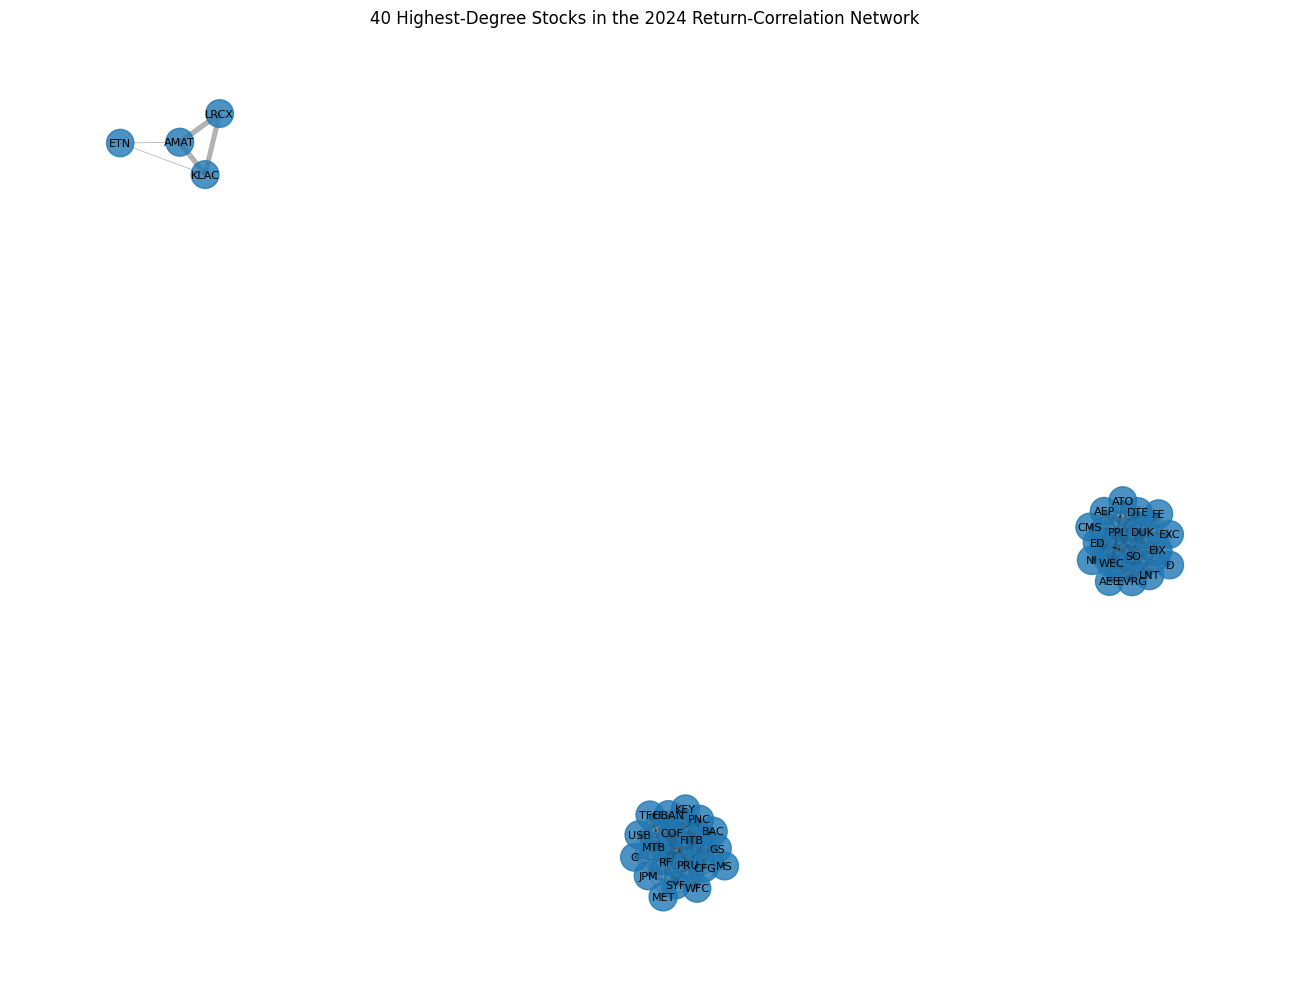

In [27]:

top_nodes = (
    metrics.nlargest(40, "Degree_Centrality")["Ticker"]
    .tolist()
)

H = G_return.subgraph(top_nodes).copy()

plt.figure(figsize=(13, 10))

pos = nx.spring_layout(
    H,
    seed=42,
    weight="weight"
)

node_sizes = [
    300 + 2500 * degree_centrality[n]
    for n in H.nodes()
]

edge_widths = [
    0.5 + 4 * ((H[u][v]["weight"] - CORR_THRESHOLD) / (1 - CORR_THRESHOLD))
    for u, v in H.edges()
]

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    H,
    pos,
    width=edge_widths,
    alpha=0.30
)

nx.draw_networkx_labels(
    H,
    pos,
    font_size=8
)

plt.title("40 Highest-Degree Stocks in the 2024 Return-Correlation Network")
plt.axis("off")
plt.tight_layout()
plt.show()



# Conclusion

I constructed a network of S&P 500 stocks using daily return correlations from 2024. Each stock was treated as a node and GICS sector was used as the categorical variable. Using a correlation threshold of 0.60, the network contained 496 stocks and 936 edges. Utilities had the highest average degree centrality at about 0.031 and also had by far the highest average eigenvector centrality. The Kruskal Wallis tests showed statistically significant differences across sectors for both degree centrality and eigenvector centrality with p values well below 0.001. This suggests that stocks from different sectors do not occupy the market network in the same way and that some sectors tend to form much stronger patterns of connectivity than others.
The network was also much more disconnected than I originally expected as the largest connected component contained a mixture of Financials, Industrials, Utilities, Information Technology, Real Estate, Consumer Discretionary, and Materials, while the second largest component was made up completely of Energy stocks.

Looking at the components separately helped explain some of the extreme differences in eigenvector centrality because it depends on which connected component a stock belongs to. Utilities was particularly important inside the largest component, while the second component had a very dense Energy network where the stocks were highly connected to one another.
I also explored a bit further by retaining correlation as an edge weight and calculating a weighted degree, weighted eigenvector centrality, and weighted clustering. Then I compared the return based network to a raw price correlation network with the same number of edges. The return based features actually produced a slightly lower cross validated MAE and slightly higher cross validated R squared when predicting 2025 excess returns, although the improvement was very small. The OLS models also explained only a small amount of the variation in future returns so I wouldn't say the network features as strong predictors on their own. The results tell me that using day over day returns is a preferred method to using raw prices and that the network structure contains useful information about how sectors move together even if it does not strongly predict future performance.
I think the biggest improvement would be to rebuild the network over shorter rolling time periods instead of using one year to predict the next. Weekly or even 3 day split networks would allow changes in centrality and edge strength to be observed over time and would create many more observations for prediction. This would hopefully make it easier to test whether changes in degree centrality, eigenvector centrality, and weighted network features have any relationship with near term future returns.
